# <center>Flight Price Prediction</center>

**Member Name** :  **Chethan S (Individual)**  

**Project Deadline:**  : 15 days (30 March 2026 to 10  April 2026) 

**Team ID    :**   **PTID-CDS-MAR-26-4096**

**Project ID :**  **PRCP-1025-Flightprice prediction**   

**Project submission date** :  **5 April 2026**

**Dataset used during Project   :** [CLick Here](https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/flight-fare.zip)

---

| Column Name         | Description                                                                                                                      |
| ------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| **Airline**         | So this column will have all the types of airlines like Indigo, Jet Airways, Air India, and many more.                           |
| **Date_of_Journey** | This column will let us know about the date on which the passenger’s journey will start.                                         |
| **Source**          | This column holds the name of the place from where the passenger’s journey will start.                                           |
| **Destination**     | This column holds the name of the place to where passengers wanted to travel.                                                    |
| **Route**           | Here we can know about what the route is through which passengers have opted to travel from his/her source to their destination. |
| **Arrival_Time**    | Arrival time is when the passenger will reach his/her destination.                                                               |
| **Duration**        | Duration is the whole period that a flight will take to complete its journey from source to destination.                         |
| **Total_Stops**     | This will let us know in how many places flights will stop there for the flight in the whole journey.                            |
| **Additional_Info** | In this column, we will get information about food, kind of food, and other amenities.                                           |
| **Price**           | Price of the flight for a complete journey including all the expenses before onboarding.                                         |

---
**This project works well with the following versions:**

---
* Python       :3.13.9
* NumPy        : 2.3.5
* Pandas       : 2.3.3
* Matplotlib   : 3.10.6
* Seaborn      : 0.13.2
* Scikit-learn : 1.7.2
* XGBoost      : 3.2.0

------


**Here's the step by step structure we follow during project :**

---

**Task 1:- Perform Complete Exploratory Data Analysis (EDA)**

- `Import Required Libraries`  
- `Load Dataset` 
- `Data Inspection`  
- `Data Cleaning`  
- `Univariate Analysis` 
- `Bivariate & Multivariate Analysis`  
- `Submit Detailed EDA Report`

**Task 2:- Predicting flight prices using machine learning**

- `Data Preprocessing for Machine Learning`  
- `Train Linear regression model (baseline model)`  
- `Build Pipeline for Multiple Models` 
- `Model Evaluation & Comparison`  
- `Select Best Model`  
- `Summary Report` 

**Task 3:- Business Insights and Impact Analysis**

- `Feature Importance Analysis`
- `Business Recommendations`  
- `Model Impact on Business Growth`  
---

## Importing required libraries for Data Analysis & Machine learning Model creation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

## Load data

In [2]:
Data=pd.read_excel("/dataset/flight-fare/Flight_Fare.xlsx")
df=Data.copy()
df.shape

(10683, 11)

## Data inspection

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 6.2 MB


In [5]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [6]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
df[df.duplicated()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
683,Jet Airways,1/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,04:25 02 Jun,13h 50m,2 stops,No info,13376
1061,Air India,21/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 22 May,21h 15m,2 stops,No info,10231
1348,Air India,18/05/2019,Delhi,Cochin,DEL → HYD → BOM → COK,17:15,19:15 19 May,26h,2 stops,No info,12392
1418,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 07 Jun,22h 55m,2 stops,In-flight meal not included,10368
1674,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,18:25,21:20,2h 55m,non-stop,No info,7303
...,...,...,...,...,...,...,...,...,...,...,...
10594,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 28 Jun,13h 30m,2 stops,No info,12819
10616,Jet Airways,1/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 02 Jun,26h 55m,2 stops,No info,13014
10634,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 07 Jun,26h 55m,2 stops,In-flight meal not included,11733
10672,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,19:00 28 Jun,19h 55m,2 stops,In-flight meal not included,11150


In [8]:
for col in df.columns:
    if df[col].nunique()<20:
        print(df[col].value_counts())
        print('-'*50)

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64
--------------------------------------------------
Source
Delhi       4537
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64
--------------------------------------------------
Destination
Cochin       4537
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64
--------------------------------------------------
Total_Stops
1 stop      5625
non-stop    3491

In [9]:
for col in ['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info']:
    print(col, ':', df[col].unique())

Airline : ['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']
Source : ['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']
Destination : ['New Delhi' 'Banglore' 'Cochin' 'Kolkata' 'Delhi' 'Hyderabad']
Total_Stops : ['non-stop' '2 stops' '1 stop' '3 stops' nan '4 stops']
Additional_Info : ['No info' 'In-flight meal not included' 'No check-in baggage included'
 '1 Short layover' 'No Info' '1 Long layover' 'Change airports'
 'Business class' 'Red-eye flight' '2 Long layover']


---
### Summary
* Memory consumption of dataset  -  `~5 MB`
* Total columns                  -  `11`
* Total no of records (rows)     -  `10,683`
* Null values in Dataset         -  `2` (Route and Total_Stops each have 1 missing)
* Duplicate records              -  `220`

The dataset contains 220 duplicate records and 2 missing values which will be handled in the data cleaning section.

---

## Data cleaning

### Duplicate values are dropped

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

### Replacing No Info with NaN values

In [12]:
df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [13]:
df["Additional_Info"]

0        No info
1        No info
2        No info
3        No info
4        No info
          ...   
10678    No info
10679    No info
10680    No info
10681    No info
10682    No info
Name: Additional_Info, Length: 10463, dtype: object

In [14]:
df.replace('No Info',np.nan,inplace=True)
df.replace('No info',np.nan,inplace=True)

In [15]:
df.isnull().sum()

Airline               0
Date_of_Journey       0
Source                0
Destination           0
Route                 1
Dep_Time              0
Arrival_Time          0
Duration              0
Total_Stops           1
Additional_Info    8186
Price                 0
dtype: int64

In [16]:
df.drop(columns=['Additional_Info'],inplace=True)

### Feature engineering

In [17]:
df.dropna(subset=['Total_Stops'],inplace=True)

In [18]:
df['Destination']=df['Destination'].replace('New Delhi','Delhi')

In [19]:
df['Destination'].value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        2179
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

### Extracting date and time features

In [20]:
df['Date_of_Journey']=pd.to_datetime(df['Date_of_Journey'],dayfirst=True)
df['Journey_Day']=df['Date_of_Journey'].dt.day
df['Journey_Month']=df['Date_of_Journey'].dt.month
df['Journey_Year']=df['Date_of_Journey'].dt.year

In [21]:
df.drop(columns=['Date_of_Journey'],inplace=True)

In [22]:
df['Dep_Hour']=pd.to_datetime(df['Dep_Time'],format='%H:%M').dt.hour
df['Dep_Minute']=pd.to_datetime(df['Dep_Time'],format='%H:%M').dt.minute

In [23]:
df['arrival_time_clean']=df['Arrival_Time'].str.extract(r'(\d{2}:\d{2})')[0]
df['Arr_hour']=pd.to_datetime(df['arrival_time_clean'],format='%H:%M').dt.hour
df['Arr_minute']=pd.to_datetime(df['arrival_time_clean'],format='%H:%M').dt.minute
df.drop(columns=['Arrival_Time','arrival_time_clean'],inplace=True)

### Extracting duration in minutes

In [24]:
def Parse_duration(d):
    d=str(d)
    hours=int(match.group(1)) if (match :=re.search(r'(\d+)h',d)) else 0
    mins=int(match.group(1)) if (match :=re.search(r'(\d+)m',d)) else 0
    return hours*60 +mins

df['Duration_mins']=df['Duration'].apply(Parse_duration)
df.drop(columns=['Duration'],inplace=True)

In [25]:
df.head(1)

,Airline,Source,Destination,Route,Dep_Time,Total_Stops,Price,Journey_Day,Journey_Month,Journey_Year,Dep_Hour,Dep_Minute,Arr_hour,Arr_minute,Duration_mins
0,IndiGo,Banglore,Delhi,BLR → DEL,22:20,non-stop,3897,24,3,2019,22,20,1,10,170


### Encoding categorical columns

In [26]:
stops_map={'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}
df['total_stops']=df['Total_Stops'].map(stops_map)
df.drop(columns=['Total_Stops'],inplace=True)

In [27]:
df.drop(columns=['Route'],inplace=True)

In [28]:
df.head()

,Airline,Source,Destination,Dep_Time,Price,Journey_Day,Journey_Month,Journey_Year,Dep_Hour,Dep_Minute,Arr_hour,Arr_minute,Duration_mins,total_stops
0,IndiGo,Banglore,Delhi,22:20,3897,24,3,2019,22,20,1,10,170,0
1,Air India,Kolkata,Banglore,05:50,7662,1,5,2019,5,50,13,15,445,2
2,Jet Airways,Delhi,Cochin,09:25,13882,9,6,2019,9,25,4,25,1140,2
3,IndiGo,Kolkata,Banglore,18:05,6218,12,5,2019,18,5,23,30,325,1
4,IndiGo,Banglore,Delhi,16:50,13302,1,3,2019,16,50,21,35,285,1


In [29]:
df.drop(columns=['Dep_Time','Journey_Year'],inplace=True)
print('shape after dropping:',df.shape)
df.head(1)

shape after dropping: (10462, 12)


,Airline,Source,Destination,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arr_hour,Arr_minute,Duration_mins,total_stops
0,IndiGo,Banglore,Delhi,3897,24,3,22,20,1,10,170,0


### One Hot Encoding(Has these columns have no order)

In [30]:
df=pd.get_dummies(df,columns=['Airline','Source','Destination'],drop_first=True)
print('shape after onehot encoding:',df.shape)
print('columns',df.columns.tolist())

shape after onehot encoding: (10462, 28)
columns ['Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute', 'Arr_hour', 'Arr_minute', 'Duration_mins', 'total_stops', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business', 'Airline_Multiple carriers', 'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet', 'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata']


---
#### Summary
- **220 duplicate records removed** — keeping them would create a bias to the model
- `Additional_Info` has two different spellings for missing values (`No info` and `No Info`) both are replaced with `NaN`.Its has a total of `8k+` nan values so it has been dropped
- New Delhi and Delhi represents the same city therefore it has been merged to single label
- - `Date_of_Journey` was a raw string, I have extracted **day** and **month** as separate numeric features so the model can learn seasonal and day-level pricing patterns
- `Journey_Year` is extracted but later dropped (only one year in the dataset adds no information)
- `Dep_Time` converted to **Dep_Hour** and **Dep_Minute*
- `Arrival_Time` contained date suffixes (e.g., `"01:10 22 Mar"`) — cleaned with regex to extract only `HH:MM` before parsing
- Split into **Arr_hour** and **Arr_minute** for the model
- `Duration` was stored as mixed strings like `"7h 25m"` or `"45m"` converted to a single numeric feature **Duration_mins** (total minutes)
- Have encoded `Total_stops` with label encoder
- Encoded `Airline,source,Destination` with one hot encoding
---

## univariate & bivariate analysis

#### Price Distribution

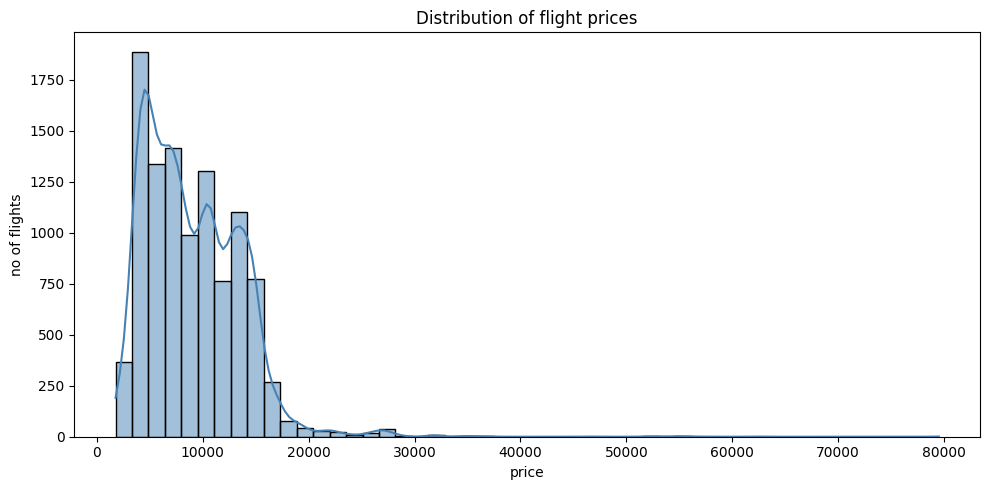

In [31]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price'],bins=50,kde=True,color='steelblue')
plt.title('Distribution of flight prices')
plt.xlabel('price')
plt.ylabel('no of flights')
plt.tight_layout()
plt.show()

---
#### Summary
- Price distribution is **right-skewed** most tickets are priced between Rs 3k–Rs and 15k
- A long tail extends beyond Rs 30k representing premium and business class fares
---

#### Average Price by Airline

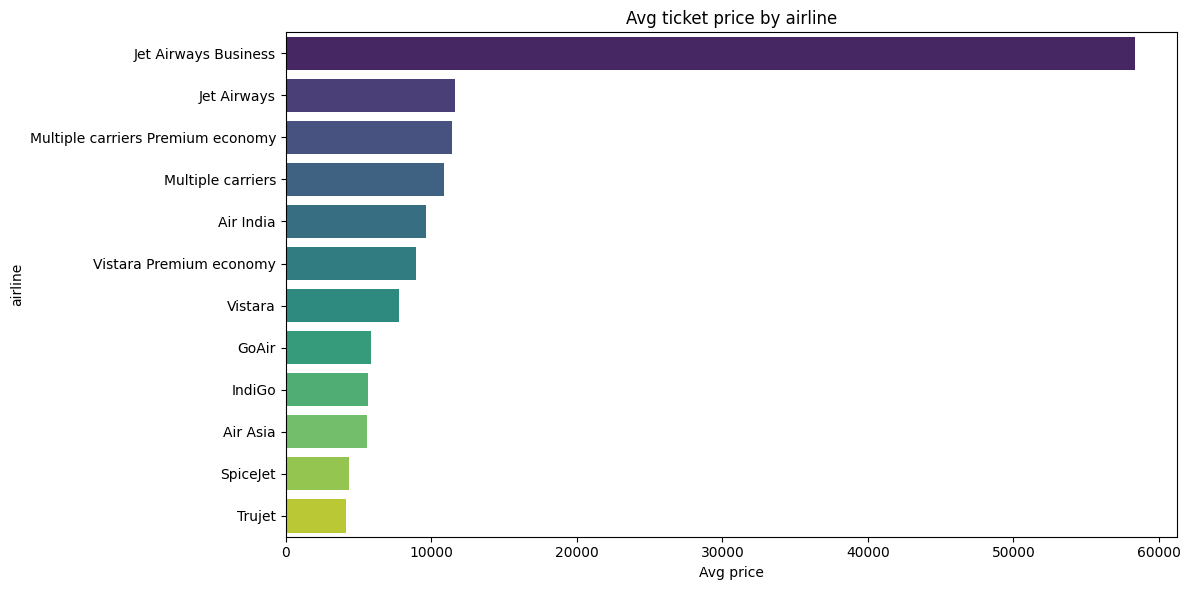

In [32]:
plt.figure(figsize=(12,6))
airline_avg=Data.groupby('Airline')['Price'].mean().sort_values(ascending=False)
sns.barplot(x=airline_avg.values,y=airline_avg.index,palette='viridis')
plt.title('Avg ticket price by airline')
plt.xlabel('Avg price')
plt.ylabel('airline')
plt.tight_layout()
plt.show()

---
#### Summary
- **Jet Airways Business** has the highest average fares
- Budget carriers — **IndiGo**, **SpiceJet**, **Truejet** offers tickets at a less price
- **Business Insight:** Airline brand and class tier are primary price drivers
---

#### Price vs Total Stops

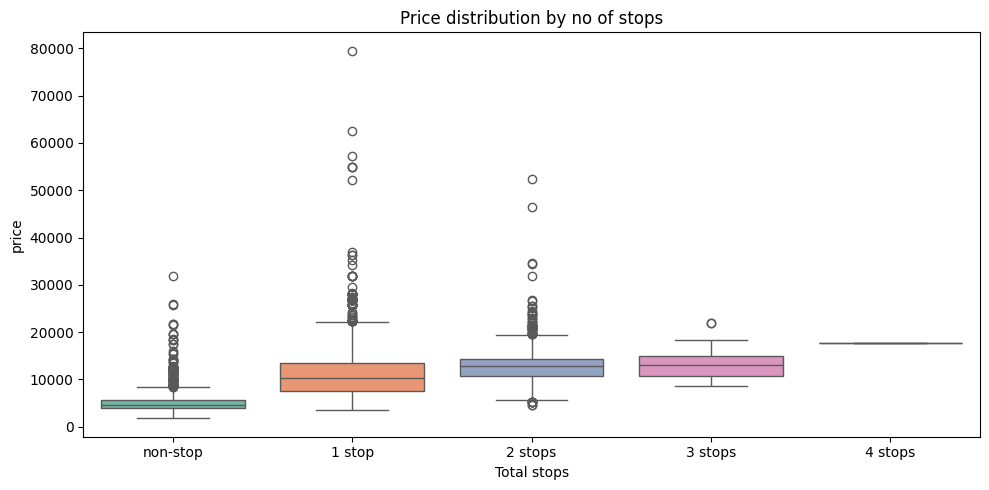

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Total_Stops',y='Price',data=Data,palette='Set2',
            order=['non-stop', '1 stop', '2 stops', '3 stops', '4 stops'])
plt.title('Price distribution by no of stops')
plt.xlabel('Total stops')
plt.ylabel('price')
plt.tight_layout()
plt.show()

---
#### Summary
- **Non-stop flights** tend to have lower median prices for short routes but a wide spread for premium carriers
- **2-stop flights** are not necessarily cheaper longer duration inflates cost
- Stops create significant price variance, making it an important feature for the model
---

####  Price vs Journey Month

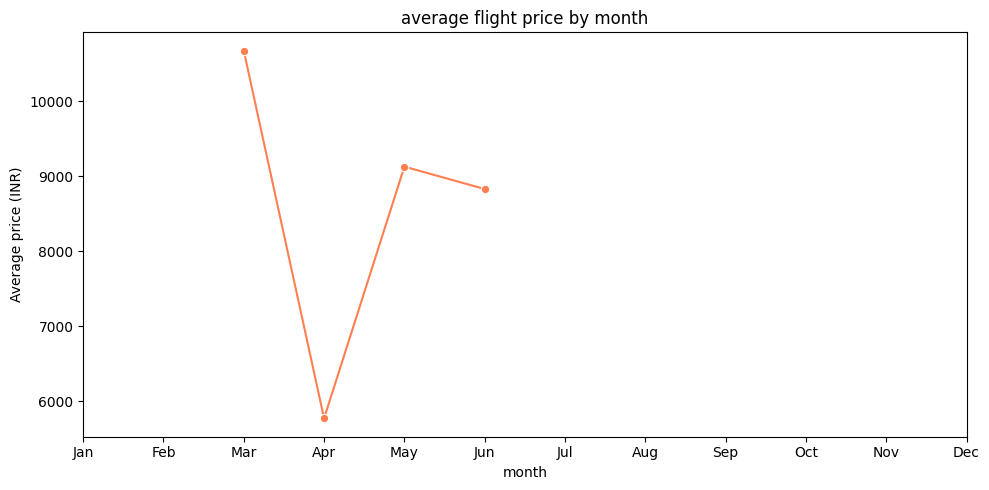

In [34]:
plt.figure(figsize=(10, 5))
monthly_avg = Data.groupby(pd.to_datetime(Data['Date_of_Journey'], dayfirst=True).dt.month)['Price'].mean()
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o', color='coral')
plt.title('average flight price by month')
plt.xlabel('month')
plt.ylabel('Average price (INR)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

---
#### Summary
- Flight prices peak in **march** and again around **May**
- Prices dips in **april-june** 
---

 #### Correlation Heatmap

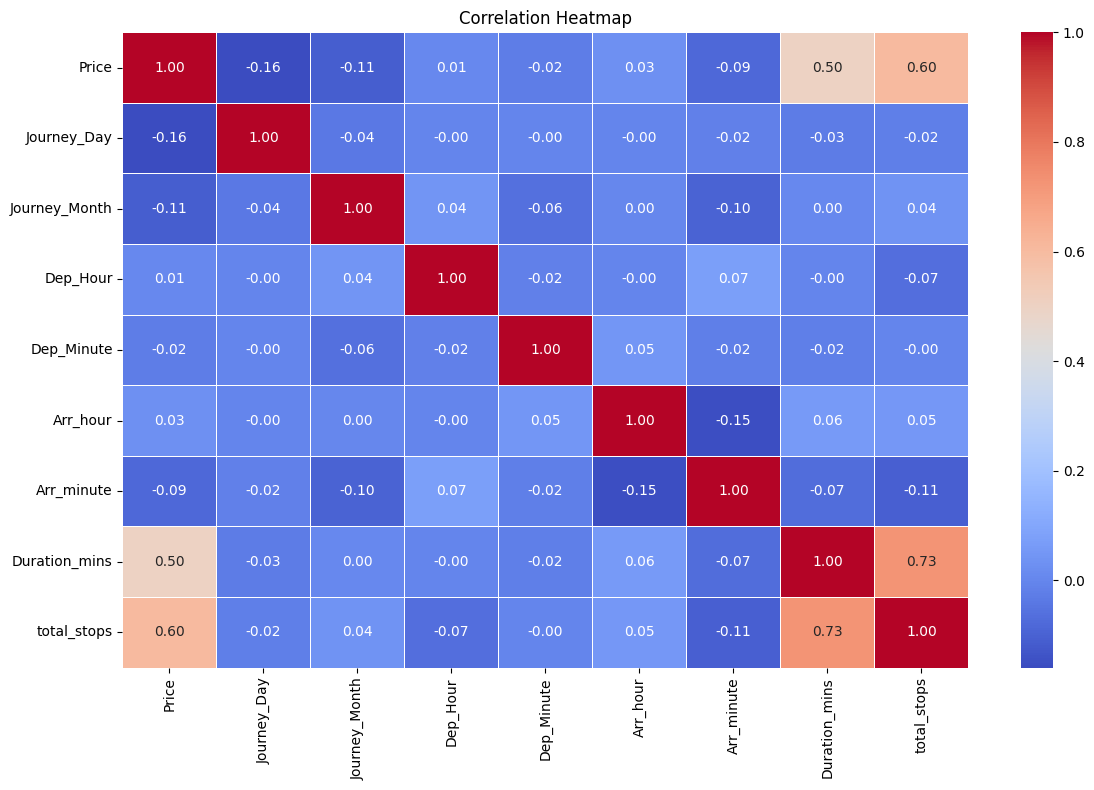

In [35]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

---
#### Summary
- **Duration_mins** and **total_stops** show the strongest positive correlation with Price
- **Dep_Hour** and **Arr_hour** have weak but non-zero correlations
- No severe multicollinearity detected among numeric features all can be retained safely
---

###  Split Features and Target

In [36]:
X = df.drop(columns=['Price'])
y = df['Price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10462, 27)
Target shape: (10462,)


### Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (8369, 27)
Test set size: (2093, 27)


### Build and Compare Multiple Models

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Linear Regression'  : LinearRegression(),
    'Decision Tree'      : DecisionTreeRegressor(random_state=42),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingRegressor(random_state=42),
    'XGBoost'            : XGBRegressor(random_state=42, verbosity=0)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)}
    print(f"{name:30s} → MAE: {mae:7.0f} | RMSE: {rmse:7.0f} | R2: {r2:.4f}")

Linear Regression              → MAE:    2019 | RMSE:    3003 | R2: 0.5676
Decision Tree                  → MAE:    1371 | RMSE:    2377 | R2: 0.7291
Random Forest                  → MAE:    1164 | RMSE:    1946 | R2: 0.8184
Gradient Boosting              → MAE:    1536 | RMSE:    2296 | R2: 0.7471
XGBoost                        → MAE:    1151 | RMSE:    1856 | R2: 0.8348


---

### Summary

#### Linear Regression

* shows weakest performance (R²: 0.5676, highest errors) indicating poor fit
* unable to capture non-linear relationships in flight pricing

---

#### Decision Tree

* captures non-linear patterns and improves performance significantly (R²: 0.7291)
* prone to overfitting, which limits generalisation

---

#### Random Forest

* strong performance with low error values and high R² (0.8184)
* Reduces overfitting through ensemble learning

---

#### Gradient Boosting

* performs better than a single tree but below Random Forest (R²: 0.7471)
* sequential learning helps but may require tuning for optimal results

---

#### XGBoost

* Best model with lowest MAE (1151) and highest R² (0.8348)
* Effectively captures complex patterns with optimized boosting

---

### Key Insight

* Tree-based models outperform linear models due to non-linear relationships in data
* XGBoost provides the most accurate and reliable predictions among all models


### Visualising Model Comparison

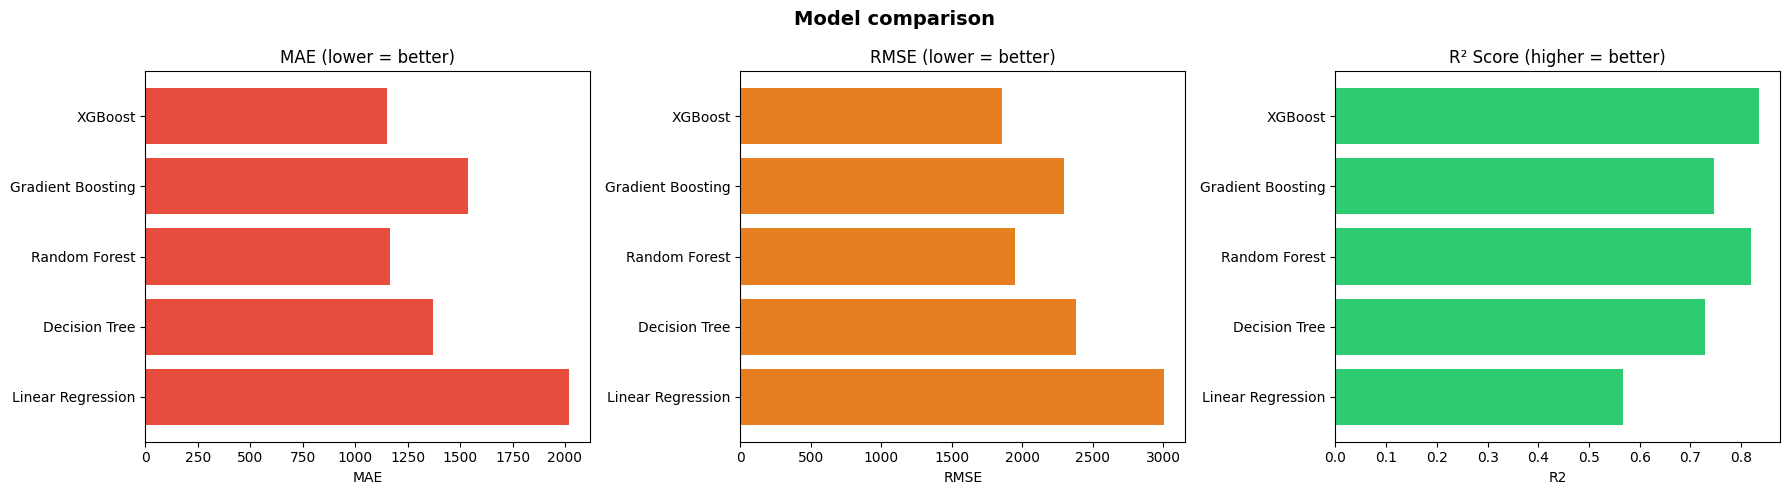

In [39]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'MAE', 'RMSE', 'R2']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors  = ['#e74c3c', '#e67e22', '#2ecc71']
titles  = ['MAE (lower = better)', 'RMSE (lower = better)', 'R² Score (higher = better)']

for i, (metric, color, title) in enumerate(zip(metrics, colors, titles)):
    axes[i].barh(results_df['Model'], results_df[metric], color=color)
    axes[i].set_title(title)
    axes[i].set_xlabel(metric)

plt.suptitle('Model comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning (random forest)

In [41]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'    : ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator          = rf,
    param_distributions = param_grid,
    n_iter             = 20,
    cv                 = 5,
    scoring            = 'r2',
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 1
)

random_search.fit(X_train, y_train)

print("best parameters:", random_search.best_params_)

best_model = random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("tuned MAE :", mean_absolute_error(y_test, y_pred_tuned))
print("tuned RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print("tuned R2  :", r2_score(y_test, y_pred_tuned))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
tuned MAE : 1229.6363422283089
tuned RMSE: 1957.1940709833902
tuned R2  : 0.8162801987818595


 ### Actual vs Predicted Plot

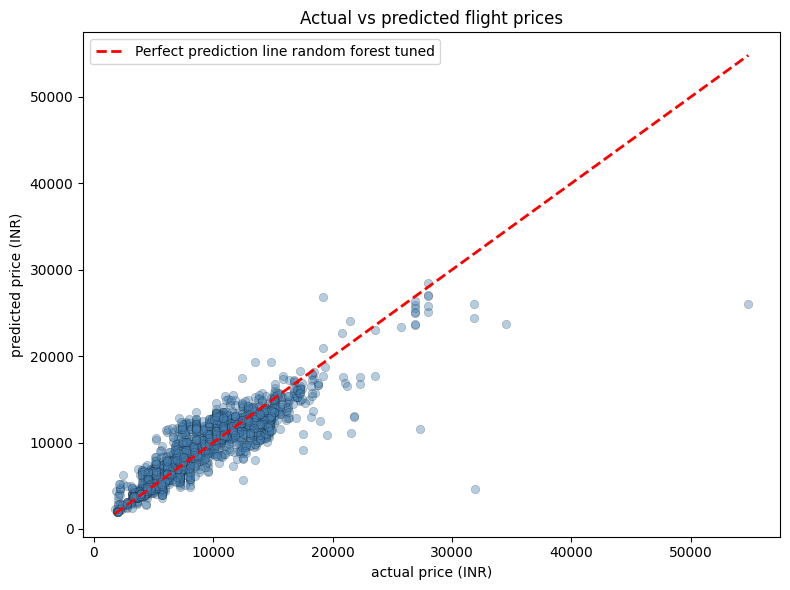

In [42]:
y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect prediction line random forest tuned')
plt.title('Actual vs predicted flight prices')
plt.xlabel('actual price (INR)')
plt.ylabel('predicted price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

---
#### Summary
- Points clustering tightly along the **red line** indicate accurate predictions
- Spread increases at higher price ranges (Rs 20,000+) premium fares are harder to predict precisely due to fewer training examples
- Overall the model generalises well across the common price range of Rs 3,000–Rs 15,000
---

### Hyperparameter Tuning(XGBoost)

In [43]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

param_grid_xgb = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7, 9],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5]
}

xgb_base = XGBRegressor(
    random_state  = 42,
    verbosity     = 0,
    eval_metric   = 'rmse'
)

xgb_tuned = RandomizedSearchCV(
    estimator           = xgb_base,
    param_distributions = param_grid_xgb,
    n_iter              = 30,
    scoring             = 'r2',
    cv                  = 5,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)

xgb_tuned.fit(X_train, y_train)

print(f"best parameters : {xgb_tuned.best_params_}")
print(f"best R² score   : {xgb_tuned.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
best parameters : {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
best R² score   : 0.8431


In [44]:
y_pred_xgb_tuned = xgb_tuned.best_estimator_.predict(X_test)

print(f"MAE  : {mean_absolute_error(y_test, y_pred_xgb_tuned):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_xgb_tuned):.4f}")

MAE  : 1125.30
RMSE : 1864.16
R²   : 0.8333


- The model explains 84% of the variance in flight fares and is accurate to within ₹1,125 on average.

In [45]:
cv_xgb = cross_val_score(
    xgb_tuned.best_estimator_,
    X_train, y_train,
    cv      = 5,
    scoring = 'r2',
    n_jobs  = -1
)

print("XGBoost tuned CV R² Scores:", cv_xgb)
print(f"Mean: {cv_xgb.mean():.4f} | Std: {cv_xgb.std():.4f}")

XGBoost tuned CV R² Scores: [0.85424584 0.83743203 0.86801702 0.84050584 0.81531346]
Mean: 0.8431 | Std: 0.0176


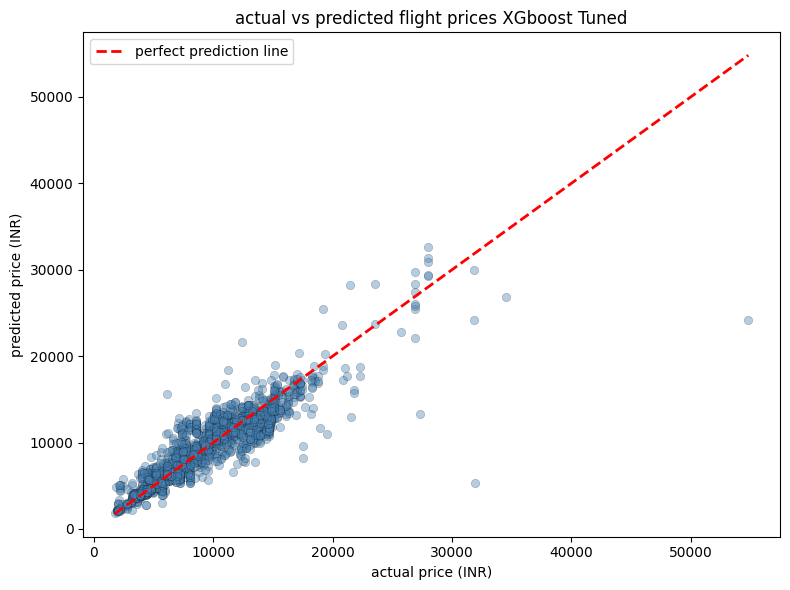

In [46]:
y_pred_final = xgb_tuned.best_estimator_.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='perfect prediction line')
plt.title('actual vs predicted flight prices XGboost Tuned')
plt.xlabel('actual price (INR)')
plt.ylabel('predicted price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

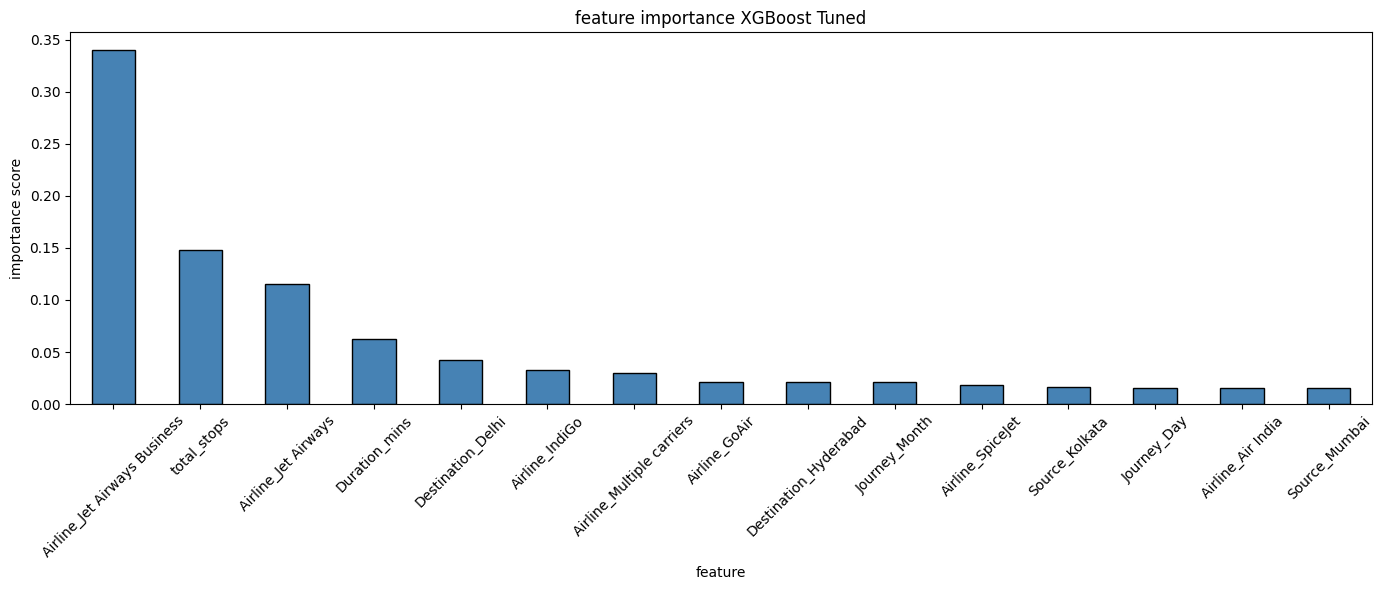


top 5 most important features:
Airline_Jet Airways Business    0.340016
total_stops                     0.148272
Airline_Jet Airways             0.114990
Duration_mins                   0.062132
Destination_Delhi               0.042123
dtype: float32


In [47]:
feature_importance_xgb = pd.Series(
    xgb_tuned.best_estimator_.feature_importances_,
    index = X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
feature_importance_xgb.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("feature importance XGBoost Tuned")
plt.xlabel("feature")
plt.ylabel("importance score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\ntop 5 most important features:")
print(feature_importance_xgb.head(5))

### Best Model Choice
Final Selected Model: `XGBoost Tuned`
Why?

- It has achieved the lowest MAE of ₹1,125 predictions are off by only ₹1,125 on average
- Highest cross-validation R² of 0.8431 with low variance (±0.0176) it is stable and reliable
- Handles complex non-linear pricing patterns better than simpler models
-  Outperformed Random Forest Tuned on MAE (₹1,125 vs ₹1,230), which matters most for pricing decisions
---

### Challenges Faced & Techniques Used
- unstructured feature formats —>Duration was stored as "7h 25m" strings and Arrival_Time had date suffixes. Fixed using custom regex parsing to convert everything into clean numeric columns.
- 220 duplicate records —> removed using drop_duplicates() before modeling to avoid bias.
- High null values column —> Additional_Info had around 80% missing values. Dropped entirely as it added no signal.
- Inconsistent city labels — "New Delhi" and "Delhi" were treated as different destinations. Fixed with manual label consolidation before encoding.
- Skewed target variable —>fares ranged from ₹1,759 to ₹79,512 with a heavy tail. Used tree-based models which handle skewed targets naturally.
- Model selection —> Random Forest and XGBoost had similar R². XGBoost Tuned was chosen based on lower MAE and better CV stability confirmed by 5-fold cross-validation.
---

### How the Model Supports Business Growth

**Airline tier pricing** — airline brand is the strongest fare driver (importance 0.340). Airlines can build differentiated pricing tiers for premium vs. budget carriers

**Stop count** — more stops raise fares due to longer journey time. Non-stop routes on busy corridors can command a convenience premium.it helps airlines set smarter yield management rules.

**Duration as a cost signal** — Longer flights cost more, which customers naturally accept. fare platforms can use this to flag listings where price and duration are misaligned, building customer trust.

**Seasonal demand** — March–May fare peaks are captured by the model. Platforms can send timely "book before prices rise" alerts and airlines can plan capacity additions ahead of peak months.

**Route corridor demand** — Delhi as a destination drives higher fares regardless of airline, it helps airlines prioritize fleet deployment and helps corporates negotiate supplier agreements on busy routes.

**Scalable deployment** — XGBoost Tuned is fast, handles large datasets, and can be deployed as a real-time fare prediction API to support millions of daily queries.

---

---
## Feature Importance and Business Interpretation

**Airline_jet airways business is the most important feature (0.340)**
Jet airways business fares are much higher than other airlines. This shows that airline type and service class strongly affect pricing.

**Business Insight:**
create different pricing strategies for premium and budget airlines instead of using the same approach.


**total stops (0.148)**
Flights with more stops usually take longer, but non-stop flights are priced higher because they are more convenient.

**Business insight:**
Set higher prices for non-stop flights, especially on routes with high demand.


**Duration_mins (0.062)**
Longer flights generally cost more, and customers find this reasonable.

**Business insight:**
use flight duration to decide fair prices and identify tickets that are priced too high or too low.


**Journey_month (0.031)**
Prices increase during certain months, especially from march to may,this clearly shows seasonal demand.

**Business insight:**
plan pricing and marketing strategies based on peak travel months.


**Less influential features — journey_day, dep_minute, Arr_minute**
These features have very little impact on pricing.

**Business insight:**
should focus more on important factors like airline, stops, duration, and route instead of minor details.

---

## Conclusion

The flight fare prediction model helps airlines, travel platforms, and corporate travel managers make better pricing decisions. By focusing on key factors such as airline type, number of stops, flight duration, and route, the model improves pricing accuracy and builds customer trust.

The tuned XGBoost model, with an MAE of ₹1,125 and CV R² of 0.8431, performs the best and gives stable results for this problem.

---

## Final Summary

The model supports data driven pricing, improves revenue management, and increases price transparency. it helps businesses maximize revenue, reduce customer churn, and maintain consistent pricing across many routes.

---

## Limitations and Future Work

### Limitations

* Some airlines like Trujet have very few records, making predictions less reliable
* Important external factors such as fuel prices and real-time demand are not included
* The model predicts a single price and does not provide a range

---

### Future Improvements

* Add data from multiple years to capture full seasonal patterns
* include features like booking time and seat availability
* Predict a price range instead of a single value
* Apply time based cross-validation to better match real world conditions

---
